In [1]:
import sklearn
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib as mpl
import scipy.io as sio
from scipy.linalg import orth
import numpy.random as npr
from sklearn.decomposition import TruncatedSVD

import sys
sys.path.insert(1, '/Users/albert/Paper-Replications/sca-REPLICATION/SCA')
from architecture import SCA_autoencoder
from model import SCA
from training import loss_func

In [2]:
device = "cpu"

## Generating Toy Data

In [3]:
def create_sine(T,C):
    tau=T/(2*np.pi)/C
    return torch.sin(torch.arange(0,T)/tau)

In [4]:
np.random.seed(0) #To get the same simulated data

T=1200 #Time
N_neurons=50 #Number of neurons
R_sim=7 #Number of dimensions in lowD representations

#Orthogonal matrix that projects low dimensional space to full neural space
V_tmp=orth(npr.randn(R_sim,N_neurons).T).T 

Z = np.zeros([T,R_sim])
for i in range(R_sim):
    Z[150*i:150*i+300,i]=create_sine(300,i+1)

#Create high-dimensional neural activity    
b=npr.randn(N_neurons) #Offset of neurons
X0=Z@V_tmp[:R_sim,:]+b #Project into high-dimensional space and add offset
X0=X0+.1*npr.randn(X0.shape[0],X0.shape[1]) #Add noise

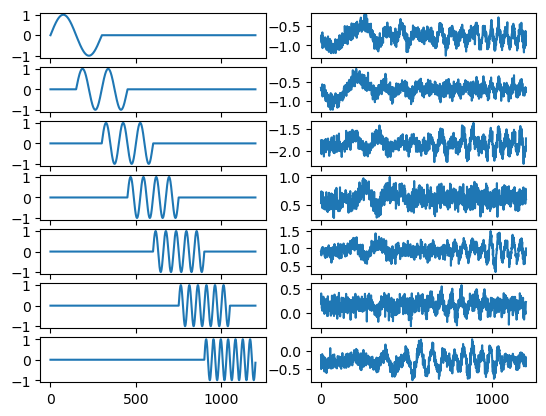

In [5]:
fig,ax = plt.subplots(R_sim,2)
for i in range(R_sim):
    ax[i,0].plot(Z[:,i])
    ax[i,1].plot(X0[:,i*3])

In [6]:
X = np.copy(X0-np.mean(X0,axis=0)[None,:])
X0_torch = torch.from_numpy(X.astype(np.float32))
n_components = 8

data = SCA(X0_torch,n_components,W=torch.eye(T),epochs=3000)

init recon: 493.13421630859375
init sparse: 49.31342697143555
init orth: 49.31342315673828
lam_sparse: 0.019221434369683266
lam_orth: 88.05968475341797


100%|██████████| 3000/3000 [00:04<00:00, 712.28it/s]


In [7]:
data['losses'][0]

tensor(542.4476, grad_fn=<SelectBackward0>)

In [8]:
def create_W(X):
        '''
        Input: T x N matrix X of T timesteps of N neurons' neural activity
        Output: Diagonal T x T matrix W, where each entry contains the inverse sum-square at that timestep
        '''
        sum_sq_activity = torch.sum(X,axis=1)**2
        inverse = 1/ sum_sq_activity
        W = torch.diag(inverse)
        return W

In [11]:
X = X0_torch
K = n_components
W = torch.eye(T)

svd = TruncatedSVD(K)
svd.fit(W@X)
U = svd.components_.T
V = svd.components_

U = torch.from_numpy(U)
V = torch.from_numpy(V)
V = V

pca_latent = X@U
pca_out = pca_latent@V

dum = SCA_autoencoder(N_neurons,K,U.T).to(device)
dum.V.weight = V.T.to(device)
hidden,out = dum(X.to(device))
dum_V = dum.V.weight

loss_func(X.to(device),W.to(device),hidden,out,dum_V,0.019221434369683266,88.05968475341797)

print(torch.sum((X.to(device)-out)**2))
print(torch.sum((X - pca_out)**2))


assert torch.allclose(torch.zeros(n_components,device=device),dum.U.bias)
assert torch.allclose(torch.zeros(N_neurons,device=device),dum.V.bias)
assert torch.allclose(V.T.to(device),dum.V.weight)
assert torch.allclose(U.T.to(device),dum.U.weight)
assert torch.allclose(hidden,pca_latent.to(device))
assert torch.allclose(out,pca_out.to(device))

tensor(492.8141, grad_fn=<SumBackward0>)
tensor(492.8141)


AssertionError: 

In [13]:
def recon_loss(m,use_device = False):
    X_ = X
    if use_device:
        X_ = X.to(device)
    return torch.sum((X_ - m)**2)

In [14]:
ex1 = X.to(device)@U.to(device)@V.to(device)
ex2_1 = X@U
ex2_2 = ex2_1@V
ex3_1 = U@V
ex3_2 = X@ex3_1
print(recon_loss(ex1,True))
print(recon_loss(ex2_2))
print(recon_loss(ex3_2))


tensor(492.8141)
tensor(492.8141)
tensor(492.8141)


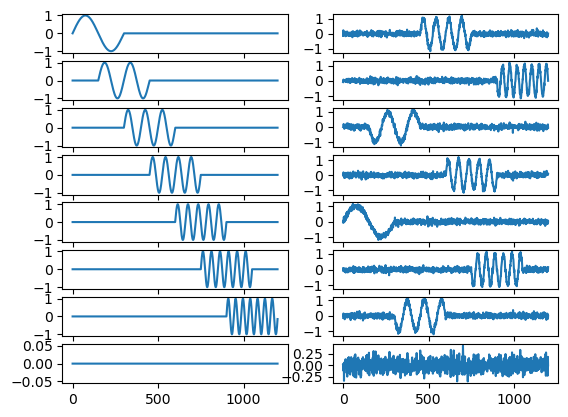

In [15]:
Extra_Z = np.zeros([T,n_components])
Extra_Z[:,:R_sim] = Z

fig,ax = plt.subplots(n_components,2)
for i in range(n_components):
    ax[i,0].plot(Extra_Z[:,i])
    ax[i,1].plot(data['latent'].cpu().detach().numpy()[:,i])